# 🛍️ Customer Segmentation & Discount Targeting
## End-to-End Scikit-Learn Workflow with Pipelines
### Clustering Algorithms: K-Means, Hierarchical (Agglomerative), and DBSCAN

---

### 📋 Overview & Objectives
In this notebook, we implement an enterprise-grade unsupervised machine learning workflow using **Scikit-Learn Pipelines** for e-commerce customer segmentation:
1. **Pipeline Architecture**: Construct automated, leakage-free pipelines using `ColumnTransformer`, `StandardScaler`, and `OneHotEncoder`.
2. **K-Means Clustering**: Determine optimal cluster count ($k$) using the **Elbow Method (Inertia/WCSS)** and **Silhouette Analysis**.
3. **Hierarchical (Agglomerative) Clustering**: Compare linkage criteria (*Ward, Complete, Average*) and visualize sample tree structures with **SciPy Dendrograms**.
4. **DBSCAN (Density-Based Spatial Clustering)**: Calibrate distance neighborhood $\varepsilon$ via **$k$-distance nearest-neighbor elbow analysis**, and detect noise/outliers.
5. **Rigorous Comparative Evaluation**: Benchmark models using **Silhouette Score**, **Davies-Bouldin Index**, and **Calinski-Harabasz Index**.
6. **Customer Persona Profiling & Business Recommendations**: Map clusters to actionable marketing strategies for discount allocation and conversion optimization.


In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
os.environ["OMP_NUM_THREADS"] = "4"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn tools
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

# Styling setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10


## 1. Data Ingestion & Exploratory Inspection

In [2]:
DATA_PATH = os.path.join("archive (3)", "customer_segmentation_discount.csv")
df = pd.read_csv(DATA_PATH)
print(f"Dataset Loaded Successfully: {df.shape[0]} rows x {df.shape[1]} columns\n")
df.head(5)


Dataset Loaded Successfully: 1000 rows x 24 columns



,user_id,age,gender,annual_income,device_mobile,traffic_source,product_category,current_session_duration_sec,time_spent_deviation,pages_viewed,...,checked_delivery_pdp,saw_checkout,sign_in,is_returning_user,lifetime_purchases_count,customer_conversion_rate,days_since_last_discount,previous_review_sentiment,social_channels_followed_count,should_receive_discount
0,usr_0001,56,0,33225.49,1,1,1,105.9,-32.8,4,...,0,0,0,0,0,0.005,999,1,1,1
1,usr_0002,46,1,65798.72,1,3,2,167.1,-18.4,4,...,0,1,1,1,3,0.150,5,1,4,0
2,usr_0003,32,0,82553.51,1,1,0,96.6,-118.1,2,...,0,1,0,0,0,0.005,999,1,1,1
3,usr_0004,60,1,76937.71,0,4,1,53.0,-166.9,1,...,0,1,0,0,0,0.005,999,1,1,1
4,usr_0005,25,1,51158.03,1,2,0,180.4,-3.3,3,...,1,1,1,1,4,0.211,30,2,0,0


In [3]:
# Identify feature categories
id_col = 'user_id'
target_col = 'should_receive_discount'
feature_cols = [c for c in df.columns if c not in [id_col, target_col]]

num_cols = [
    'age', 'annual_income', 'current_session_duration_sec', 'time_spent_deviation',
    'pages_viewed', 'cart_items_count_this_session', 'cart_total_value',
    'lifetime_purchases_count', 'customer_conversion_rate', 'days_since_last_discount',
    'social_channels_followed_count'
]
cat_cols = ['traffic_source', 'product_category', 'previous_review_sentiment']
bin_cols = [
    'gender', 'device_mobile', 'basket_icon_click', 'scrolled_to_reviews',
    'checked_delivery_pdp', 'saw_checkout', 'sign_in', 'is_returning_user'
]

print(f"Continuous Numerical Features: {len(num_cols)}")
print(f"Categorical Features:          {len(cat_cols)}")
print(f"Binary Features:               {len(bin_cols)}")


Continuous Numerical Features: 11
Categorical Features:          3
Binary Features:               8


## 2. Scikit-Learn Preprocessing Pipeline
We build a modular `ColumnTransformer` to handle numerical scaling and categorical encoding simultaneously:
- **Numerical**: `StandardScaler` ($\mu=0, \sigma=1$)
- **Categorical**: `OneHotEncoder(drop='first', sparse_output=False)`
- **Binary**: Passthrough


In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols),
        ('bin', 'passthrough', bin_cols)
    ],
    remainder='drop'
)

# Fit and transform features
X_preprocessed = preprocessor.fit_transform(df[feature_cols])
print(f"Preprocessed feature matrix shape: {X_preprocessed.shape}")

# 2D PCA for visualization & spatial analysis
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_preprocessed)
print(f"PCA Variance Explained: PC1 = {pca_2d.explained_variance_ratio_[0]*100:.2f}%, PC2 = {pca_2d.explained_variance_ratio_[1]*100:.2f}%")


Preprocessed feature matrix shape: (1000, 27)
PCA Variance Explained: PC1 = 21.83%, PC2 = 18.79%


## 3. K-Means Clustering & Hyperparameter Tuning
We evaluate $k \in [2, 10]$ using:
- **Within-Cluster Sum of Squares (Inertia / WCSS)** to locate the elbow bend
- **Silhouette Coefficient** to assess inter-cluster separation vs intra-cluster cohesion


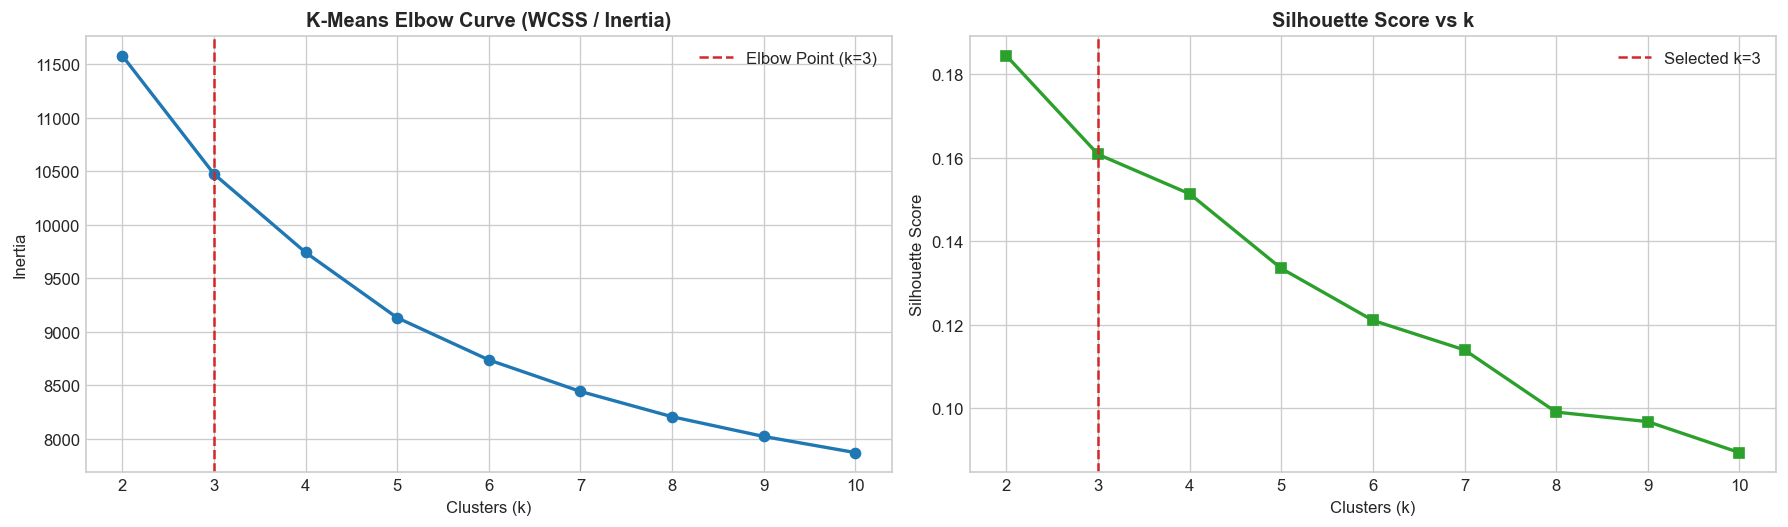

In [5]:
k_range = range(2, 11)
wcss = []
sil_scores = []
db_scores = []
ch_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = km.fit_predict(X_preprocessed)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_preprocessed, labels))
    db_scores.append(davies_bouldin_score(X_preprocessed, labels))
    ch_scores.append(calinski_harabasz_score(X_preprocessed, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5))

# Elbow plot
ax1.plot(k_range, wcss, marker='o', color='#1f77b4', lw=2)
ax1.set_title("K-Means Elbow Curve (WCSS / Inertia)", fontweight='bold')
ax1.set_xlabel("Clusters (k)")
ax1.set_ylabel("Inertia")
ax1.axvline(x=3, color='#d62728', linestyle='--', label='Elbow Point (k=3)')
ax1.legend()

# Silhouette Score plot
ax2.plot(k_range, sil_scores, marker='s', color='#2ca02c', lw=2)
ax2.set_title("Silhouette Score vs k", fontweight='bold')
ax2.set_xlabel("Clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.axvline(x=3, color='#d62728', linestyle='--', label='Selected k=3')
ax2.legend()

plt.tight_layout()
plt.show()


In [6]:
# Final K-Means Pipeline
kmeans_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('cluster', KMeans(n_clusters=3, init='k-means++', n_init=20, random_state=42))
])
kmeans_pipeline.fit(df[feature_cols])
df['cluster_kmeans'] = kmeans_pipeline.named_steps['cluster'].labels_
print("K-Means Pipeline fitted successfully. Cluster distribution:")
print(df['cluster_kmeans'].value_counts().sort_index())


K-Means Pipeline fitted successfully. Cluster distribution:
cluster_kmeans
0    386
1    411
2    203
Name: count, dtype: int64


## 4. Hierarchical (Agglomerative) Clustering & Dendrogram
We test different linkage metrics (*Ward, Complete, Average*) and plot a **SciPy Dendrogram** representing agglomeration steps.


Linkage: ward     | Silhouette: 0.1477 | Davies-Bouldin: 2.0400
Linkage: complete | Silhouette: 0.1336 | Davies-Bouldin: 2.1210
Linkage: average  | Silhouette: 0.1980 | Davies-Bouldin: 0.8526


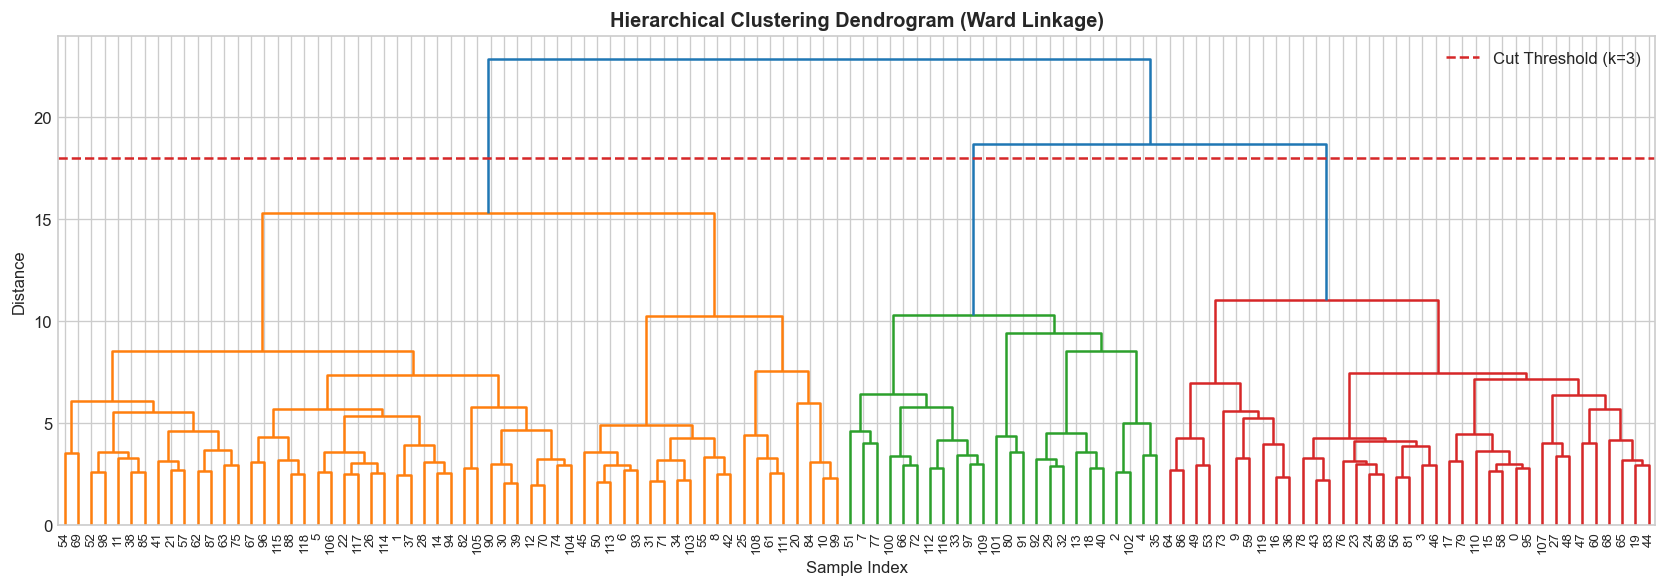

In [7]:
for method in ['ward', 'complete', 'average']:
    agg = AgglomerativeClustering(n_clusters=3, linkage=method)
    lbls = agg.fit_predict(X_preprocessed)
    print(f"Linkage: {method:8s} | Silhouette: {silhouette_score(X_preprocessed, lbls):.4f} | Davies-Bouldin: {davies_bouldin_score(X_preprocessed, lbls):.4f}")

# Dendrogram on customer subset for visual clarity
np.random.seed(42)
sample_idx = np.random.choice(len(X_preprocessed), size=120, replace=False)
Z = linkage(X_preprocessed[sample_idx], method='ward', metric='euclidean')

plt.figure(figsize=(14, 5))
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)", fontweight='bold')
plt.xlabel("Sample Index")
plt.ylabel("Distance")
dendrogram(Z, leaf_rotation=90, leaf_font_size=8, color_threshold=18)
plt.axhline(y=18, color='#d62728', linestyle='--', label='Cut Threshold (k=3)')
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
# Agglomerative Pipeline
hierarchical_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('cluster', AgglomerativeClustering(n_clusters=3, linkage='ward'))
])
hierarchical_pipeline.fit(df[feature_cols])
df['cluster_hierarchical'] = hierarchical_pipeline.named_steps['cluster'].labels_
print("Hierarchical Pipeline fitted successfully. Cluster distribution:")
print(df['cluster_hierarchical'].value_counts().sort_index())


Hierarchical Pipeline fitted successfully. Cluster distribution:
cluster_hierarchical
0    439
1    417
2    144
Name: count, dtype: int64


## 5. DBSCAN (Density-Based Spatial Clustering)
DBSCAN finds core points of high density and marks outliers as noise (label `-1`). We determine $\varepsilon$ using the **$k$-Nearest Neighbors distance knee**.


In [9]:
# K-distance graph
k_nn = 5
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(X_preprocessed)
distances, _ = nbrs.kneighbors(X_preprocessed)
k_dist = np.sort(distances[:, k_nn - 1])

plt.figure(figsize=(8, 4))
plt.plot(k_dist, color='#9467bd', lw=2)
plt.title("DBSCAN k-Distance Graph (k=5)", fontweight='bold')
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k_nn}-th Nearest Neighbor Distance")
plt.axhline(y=2.8, color='#d62728', linestyle='--', label=r'Selected $arepsilon = 2.8$')
plt.legend()
plt.show()


ValueError: 
Selected $arepsilon = 2.8$
         ^
ParseException: Expected end of text, found '$'  (at char 9), (line:1, col:10)

<Figure size 960x480 with 1 Axes>

In [10]:
# DBSCAN Pipeline in Full Dimension (eps=2.8, min_samples=4)
dbscan_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('cluster', DBSCAN(eps=2.8, min_samples=4))
])
dbscan_pipeline.fit(df[feature_cols])
df['cluster_dbscan'] = dbscan_pipeline.named_steps['cluster'].labels_

# Also fit DBSCAN on 2D PCA projection for spatial density comparison
dbscan_pca = DBSCAN(eps=0.55, min_samples=10).fit(X_pca_2d)
df['cluster_dbscan_pca'] = dbscan_pca.labels_

print("DBSCAN Full-Dimension Clusters:", set(df['cluster_dbscan']))
print("DBSCAN Full-Dimension Noise Points:", (df['cluster_dbscan'] == -1).sum())
print("DBSCAN 2D PCA Clusters:", set(df['cluster_dbscan_pca']))
print("DBSCAN 2D PCA Noise Points:", (df['cluster_dbscan_pca'] == -1).sum())


DBSCAN Full-Dimension Clusters: {0, 1, -1}
DBSCAN Full-Dimension Noise Points: 136
DBSCAN 2D PCA Clusters: {0, 1, -1}
DBSCAN 2D PCA Noise Points: 22


## 6. Comprehensive Performance Comparison Matrix

In [11]:
def evaluate_clusters(X, labels, model_name):
    mask = labels != -1
    num_clusters = len(set(labels[mask]))
    noise = (labels == -1).sum()
    if num_clusters > 1:
        sil = round(silhouette_score(X[mask], labels[mask]), 4)
        db = round(davies_bouldin_score(X[mask], labels[mask]), 4)
        ch = round(calinski_harabasz_score(X[mask], labels[mask]), 2)
    else:
        sil, db, ch = 'N/A', 'N/A', 'N/A'
    return {
        'Algorithm': model_name,
        'Clusters': num_clusters,
        'Noise Points': f"{noise} ({noise/len(labels)*100:.1f}%)",
        'Silhouette (High)': sil,
        'Davies-Bouldin (Low)': db,
        'Calinski-Harabasz (High)': ch
    }

comparison_df = pd.DataFrame([
    evaluate_clusters(X_preprocessed, df['cluster_kmeans'], "K-Means (k=3)"),
    evaluate_clusters(X_preprocessed, df['cluster_hierarchical'], "Hierarchical (Ward, k=3)"),
    evaluate_clusters(X_preprocessed, df['cluster_dbscan'], "DBSCAN (Full Dim, eps=2.8, ms=4)"),
    evaluate_clusters(X_pca_2d, df['cluster_dbscan_pca'], "DBSCAN (2D PCA, eps=0.55, ms=10)")
])
comparison_df


,Algorithm,Clusters,Noise Points,Silhouette (High),Davies-Bouldin (Low),Calinski-Harabasz (High)
0,K-Means (k=3),3,0 (0.0%),0.1608,1.8508,182.95
1,"Hierarchical (Ward, k=3)",3,0 (0.0%),0.1477,2.0400,153.90
2,"DBSCAN (Full Dim, eps=2.8, ms=4)",2,136 (13.6%),0.0926,1.4437,6.87
3,"DBSCAN (2D PCA, eps=0.55, ms=10)",2,22 (2.2%),0.4873,0.8695,938.29


## 7. 2D PCA Visual Cluster Comparison

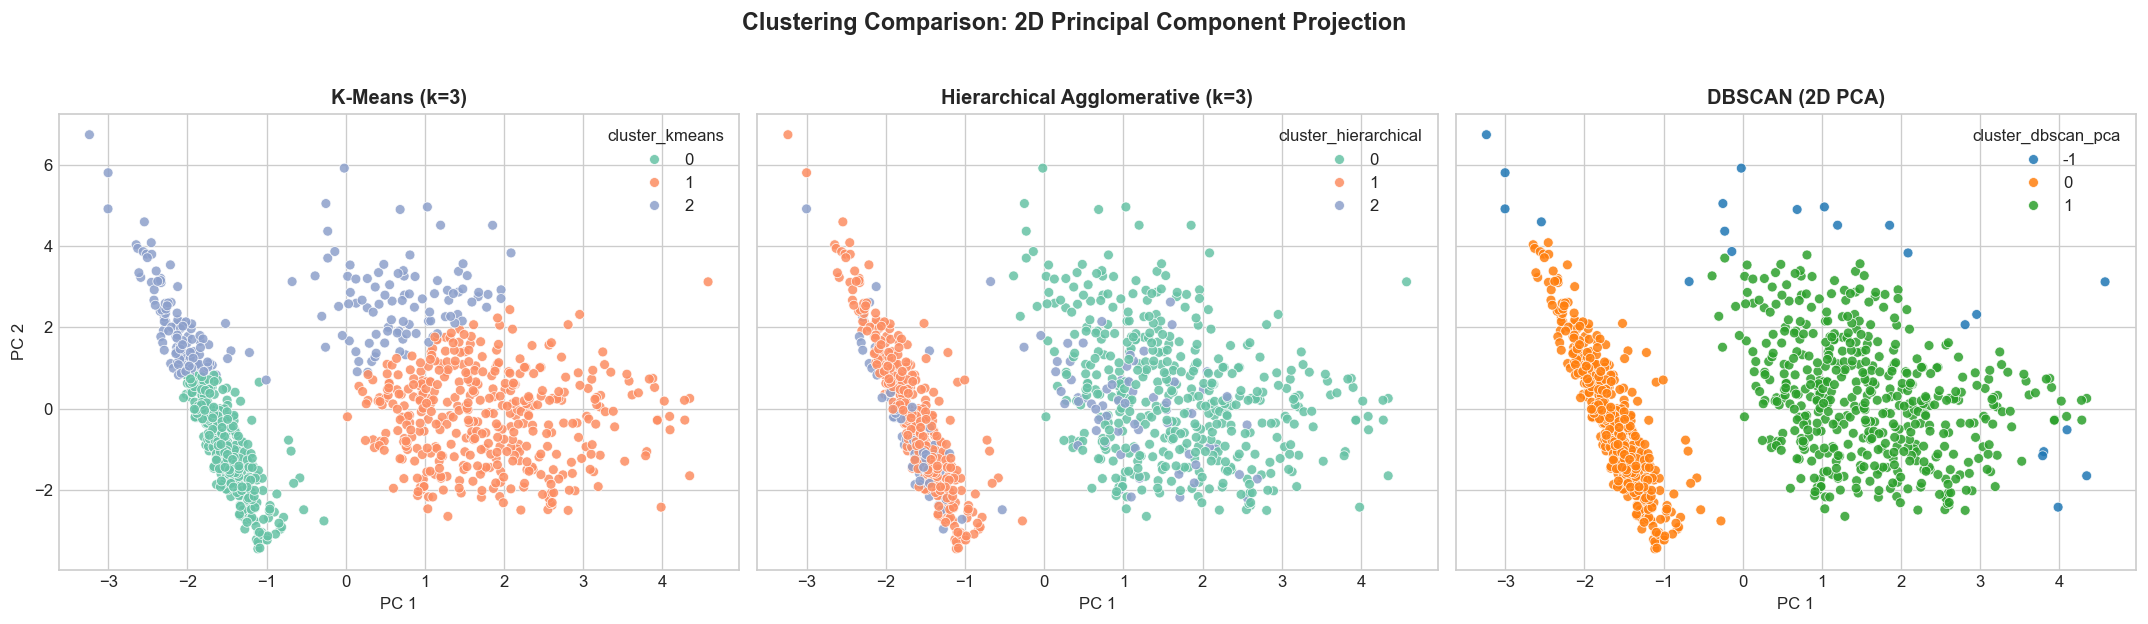

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# 1. K-Means
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=df['cluster_kmeans'], palette='Set2', ax=axes[0], s=35, alpha=0.85)
axes[0].set_title("K-Means (k=3)", fontweight='bold')
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")

# 2. Hierarchical
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=df['cluster_hierarchical'], palette='Set2', ax=axes[1], s=35, alpha=0.85)
axes[1].set_title("Hierarchical Agglomerative (k=3)", fontweight='bold')
axes[1].set_xlabel("PC 1")

# 3. DBSCAN
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=df['cluster_dbscan_pca'], palette='tab10', ax=axes[2], s=35, alpha=0.85)
axes[2].set_title("DBSCAN (2D PCA)", fontweight='bold')
axes[2].set_xlabel("PC 1")

plt.suptitle("Clustering Comparison: 2D Principal Component Projection", fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


## 8. Customer Segment Profiling & Business Recommendations

In [13]:
key_profile_cols = [
    'annual_income', 'age', 'current_session_duration_sec', 'pages_viewed',
    'cart_items_count_this_session', 'cart_total_value', 'lifetime_purchases_count',
    'customer_conversion_rate', 'days_since_last_discount', 'is_returning_user',
    'sign_in', 'saw_checkout', 'should_receive_discount'
]

profile = df.groupby('cluster_kmeans')[key_profile_cols].mean().T
profile.columns = [f"Segment {c}" for c in profile.columns]
profile.loc['Customer Count'] = df['cluster_kmeans'].value_counts().sort_index().values
profile.loc['Segment Share (%)'] = (df['cluster_kmeans'].value_counts().sort_index() / len(df) * 100).values
profile.round(2)


,Segment 0,Segment 1,Segment 2
annual_income,56822.25,56013.47,53753.95
age,40.85,40.69,41.84
current_session_duration_sec,151.60,156.98,335.00
pages_viewed,3.73,3.88,7.06
cart_items_count_this_session,1.31,1.20,1.56
cart_total_value,43.17,41.34,54.18
lifetime_purchases_count,0.00,3.20,1.17
customer_conversion_rate,0.00,0.19,0.06
days_since_last_discount,999.00,67.13,570.52
is_returning_user,0.03,1.00,0.49


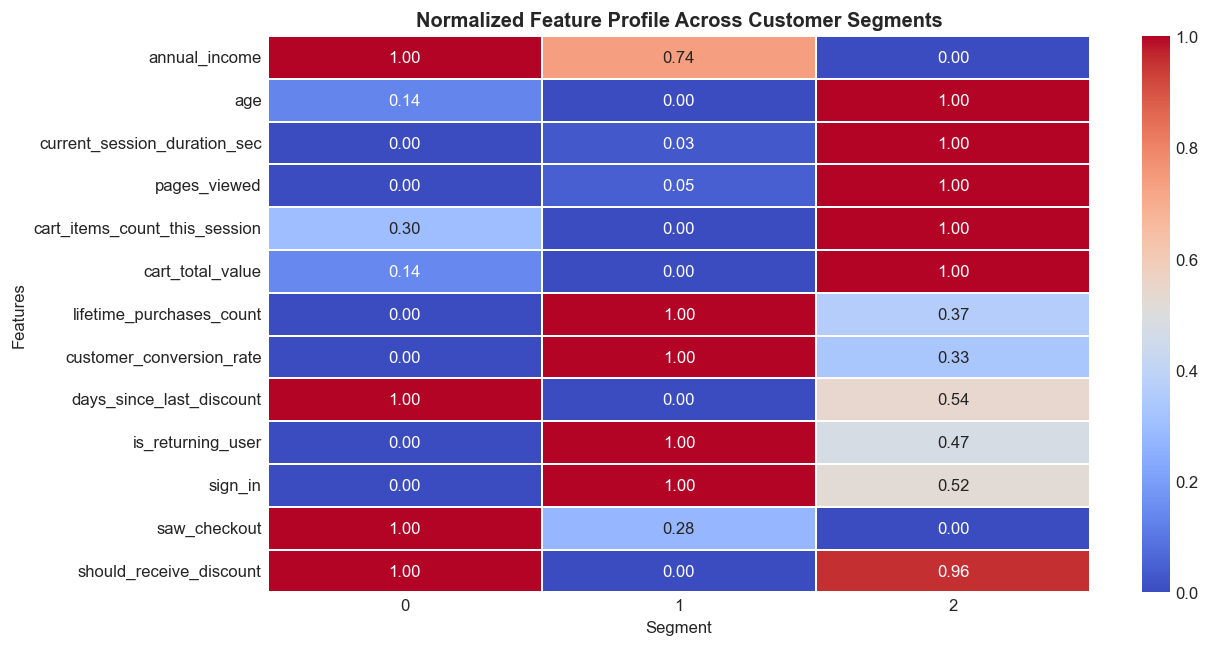

In [14]:
# Heatmap of normalized customer traits
norm_profile = df.groupby('cluster_kmeans')[key_profile_cols].mean()
norm_profile = (norm_profile - norm_profile.min()) / (norm_profile.max() - norm_profile.min() + 1e-9)

plt.figure(figsize=(11, 5.5))
sns.heatmap(norm_profile.T, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title("Normalized Feature Profile Across Customer Segments", fontweight='bold')
plt.xlabel("Segment")
plt.ylabel("Features")
plt.tight_layout()
plt.show()
